# Lab 11: Home exercise

* Student: Phạm Trần Minh Trí  
* ID: 2313622  
* Dataset: https://huggingface.co/datasets/Salesforce/wikitext

Import libraries

In [1]:
%pip install -q lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 17.8 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.


In [41]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorForLanguageModeling
import torch
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader
import torch.nn.functional as F
import lightning as L
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.callbacks import ModelCheckpoint
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load data

Download dataset

In [3]:
dataset = load_dataset("wikitext", "wikitext-103-v1")

README.md: 0.00B [00:00, ?B/s]

wikitext-103-v1/test-00000-of-00001.parq(…):   0%|          | 0.00/722k [00:00<?, ?B/s]

wikitext-103-v1/train-00000-of-00002.par(…):   0%|          | 0.00/156M [00:00<?, ?B/s]

wikitext-103-v1/train-00001-of-00002.par(…):   0%|          | 0.00/156M [00:00<?, ?B/s]

wikitext-103-v1/validation-00000-of-0000(…):   0%|          | 0.00/655k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

## 2. Preprocess data

Hyperparameters

In [32]:
MAX_SEQ_LEN = 256  # sequence length for each data sample
BATCH_SIZE = 32  # number of sample in each batch for training
LEARNING_RATE = 1e-3
MAX_EPOCHS = 2  # number of train epoch
NUM_WORKERS = 4  # number of cpu core for loading data
VAL_STEPS = 500  # number of training batches before validation and checkpoint
PATIENCE = 10  # number of val check before early stopping

Using GPT2 tokenizer

In [5]:
tokenizer = AutoTokenizer.from_pretrained("openai-community/gpt2")
tokenizer.pad_token = tokenizer.eos_token  # gpt2 does not have pad token

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenize the dataset

In [6]:
tokenized_dataset = dataset.map(
    lambda example: tokenizer(example["text"]), batched=True
)

Map:   0%|          | 0/4358 [00:00<?, ? examples/s]

Map:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1059 > 1024). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/3760 [00:00<?, ? examples/s]

Turn to chunks of 256 tokens

In [7]:
def group_texts(examples):
    keys = ["input_ids", "attention_mask"]
    concat_examples = {}
    for key in keys:
        concat_examples[key] = sum(examples[key], [])

    total_len = len(concat_examples["input_ids"])

    result_data = {}
    for key, value in concat_examples.items():
        result_data[key] = [
            value[i : i + MAX_SEQ_LEN] for i in range(0, total_len, MAX_SEQ_LEN)
        ]

    return result_data


column_names = tokenized_dataset["train"].column_names
grouped_dataset = tokenized_dataset.map(
    function=group_texts, batched=True, remove_columns=column_names
)

Map:   0%|          | 0/4358 [00:00<?, ? examples/s]

Map:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Map:   0%|          | 0/3760 [00:00<?, ? examples/s]

Set pytorch format

In [8]:
grouped_dataset.set_format("torch")

Add data collator for creating batch

In [9]:
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

Create dataloader

In [10]:
train_loader = DataLoader(
    dataset=grouped_dataset["train"],
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=data_collator,
)
val_loader = DataLoader(
    dataset=grouped_dataset["validation"],
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=data_collator,
)
test_loader = DataLoader(
    dataset=grouped_dataset["test"],
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=data_collator,
)

## 3. Create model

Positional encoding

In [34]:
class CausalLanguageModel(L.LightningModule):
    def __init__(
        self,
        vocab_size: int,
        d_model: int = 512,
        max_seq_len: int = MAX_SEQ_LEN,
        n_heads: int = 8,
        n_layers: int = 6,
    ):
        super().__init__()
        self.vocab_size = vocab_size

        self.token_embedding = nn.Embedding(
            num_embeddings=vocab_size, embedding_dim=d_model
        )
        self.pos_embedding = nn.Embedding(
            num_embeddings=max_seq_len, embedding_dim=d_model
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer=nn.TransformerEncoderLayer(
                d_model=d_model, nhead=n_heads, batch_first=True, norm_first=True
            ),
            num_layers=n_layers,
            enable_nested_tensor=False,
        )
        self.fc = nn.Linear(in_features=d_model, out_features=vocab_size)

    def forward(self, input_ids, attention_mask):
        """
        - input_ids: (batch_size, seq_len)
        - attention_mask: (batch_size, seq_len)
        """
        batch_size, seq_len = input_ids.size()

        positions = torch.arange(0, seq_len, device=self.device)
        x = self.token_embedding(input_ids) + self.pos_embedding(positions)

        causal_mask = nn.Transformer.generate_square_subsequent_mask(
            sz=seq_len, device=self.device, dtype=torch.bool
        )
        padding_mask = attention_mask == 0
        x = self.transformer(
            src=x, mask=causal_mask, src_key_padding_mask=padding_mask, is_causal=True
        )

        logits = self.fc(x)
        return logits

    def training_step(self, batch, batch_idx):
        input_ids = batch["input_ids"][:, :-1]  # (batch_size, seq_len)
        attention_mask = batch["attention_mask"][:, :-1]  # (batch_size, seq_len)
        labels: torch.Tensor = batch["input_ids"][:, 1:]  # (batch_size, seq_len)

        logits: torch.Tensor = self(
            input_ids, attention_mask
        )  # (batch_size, seq_len, vocab_size)

        flatten_logits = logits.reshape(
            -1, self.vocab_size
        )  # (batch_size * seq_len, vocab_size)
        flatten_labels = labels.reshape(-1)  # (batch_size * seq_len)

        loss = F.cross_entropy(flatten_logits, flatten_labels)
        self.log("train_loss", loss)

        accuracy = (flatten_logits.argmax(1) == flatten_labels).float().mean()
        self.log("train_acc", accuracy)

        return loss

    def validation_step(self, batch, batch_idx):
        input_ids = batch["input_ids"][:, :-1]  # (batch_size, seq_len)
        attention_mask = batch["attention_mask"][:, :-1]  # (batch_size, seq_len)
        labels: torch.Tensor = batch["input_ids"][:, 1:]  # (batch_size, seq_len)

        logits: torch.Tensor = self(
            input_ids, attention_mask
        )  # (batch_size, seq_len, vocab_size)

        flatten_logits = logits.reshape(
            -1, self.vocab_size
        )  # (batch_size * seq_len, vocab_size)
        flatten_labels = labels.reshape(-1)  # (batch_size * seq_len)

        loss = F.cross_entropy(flatten_logits, flatten_labels)
        self.log("val_loss", loss)

        accuracy = (flatten_logits.argmax(1) == flatten_labels).float().mean()
        self.log("val_acc", accuracy)

    def test_step(self, batch, batch_idx):
        input_ids = batch["input_ids"][:, :-1]  # (batch_size, seq_len)
        attention_mask = batch["attention_mask"][:, :-1]  # (batch_size, seq_len)
        labels: torch.Tensor = batch["input_ids"][:, 1:]  # (batch_size, seq_len)

        logits: torch.Tensor = self(
            input_ids, attention_mask
        )  # (batch_size, seq_len, vocab_size)

        flatten_logits = logits.reshape(
            -1, self.vocab_size
        )  # (batch_size * seq_len, vocab_size)
        flatten_labels = labels.reshape(-1)  # (batch_size * seq_len)

        loss = F.cross_entropy(flatten_logits, flatten_labels)
        self.log("test_loss", loss)

        accuracy = (flatten_logits.argmax(1) == flatten_labels).float().mean()
        self.log("test_acc", accuracy)

    def configure_optimizers(self):
        optimizer = AdamW(params=self.parameters(), lr=LEARNING_RATE)
        return optimizer


model = CausalLanguageModel(vocab_size=tokenizer.vocab_size)

## 4. Training

In [35]:
trainer = L.Trainer(
    # limit_train_batches=500,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=PATIENCE),
        ModelCheckpoint(monitor="val_loss", every_n_train_steps=VAL_STEPS),
    ],
    max_epochs=MAX_EPOCHS,
    val_check_interval=VAL_STEPS,
    # max_epochs=50,
    # overfit_batches=1,
    # enable_checkpointing=False,
    # log_every_n_steps=1
)
trainer.fit(model, train_loader, val_loader)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ token_embedding │ Embedding          │ 25.7 M │ train │     0 │
│ 1 │ pos_embedding   │ Embedding          │  131 K │ train │     0 │
│ 2 │ transformer     │ TransformerEncoder │ 18.9 M │ train │     0 │
│ 3 │ fc              │ Linear             │ 25.8 M │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 70.6 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 70.6 M                                                                                               
Total estimated model params size (MB): 282                                                                        
Modules in train mode: 65                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=2` reached.


Test the model on test set after training complete

In [36]:
trainer.test(dataloaders=test_loader)

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/checkpoint_connector.py:149: `.test(ckpt_path=None)` was called without a model. The best model of the previous `fit` call will be used. You can pass `.test(ckpt_path='best')` to use the best model or `.test(ckpt_path='last')` to use the last model. If you pass a value, this warning will be silenced.
Restoring states from the checkpoint path at /kaggle/working/lightning_logs/version_5/checkpoints/epoch=1-step=28000.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loaded model weights from the checkpoint at /kaggle/working/lightning_logs/version_5/checkpoints/epoch=1-step=28000.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.37554165720939636    │
│         test_loss         │    3.5758368968963623     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 3.5758368968963623, 'test_acc': 0.37554165720939636}]

## 5. Result

If you have TensorBoard installed, run `tensorboard --logdir .` to view the loss and accuracy graph of training and validation loop. Below are the author's train graph. Trained weights can be found [here](https://drive.google.com/drive/folders/1_qqYVNR6jyl7XBKeuAVDTiIjakLprKCf?usp=sharing)

In [45]:
!gdown 1HRHNelD43cHyg6fh8u1Ay0sGFLB-QfNx --folder

Retrieving folder contents
Processing file 1_wcvmgl6xGQIDeaz_256Lrvu-oH2kjwg train_acc.csv
Processing file 1bvsI5vacieS3LG1SJr3qmTacY3DVelja train_loss.csv
Processing file 1L2rbg1TdcXXdTlDQNttllYB05c6wDdu7 val_acc.csv
Processing file 1cjBrCeTpnIwfIsAVP9akrKGwkwZkp2J0 val_loss.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1_wcvmgl6xGQIDeaz_256Lrvu-oH2kjwg
To: /kaggle/working/csv_log/train_acc.csv
100%|██████████████████████████████████████| 25.8k/25.8k [00:00<00:00, 61.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1bvsI5vacieS3LG1SJr3qmTacY3DVelja
To: /kaggle/working/csv_log/train_loss.csv
100%|██████████████████████████████████████| 25.1k/25.1k [00:00<00:00, 50.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1L2rbg1TdcXXdTlDQNttllYB05c6wDdu7
To: /kaggle/working/csv_log/val_acc.csv
100%|██████████████████████████████████████| 2.53k/2.53k [00:00<00:00

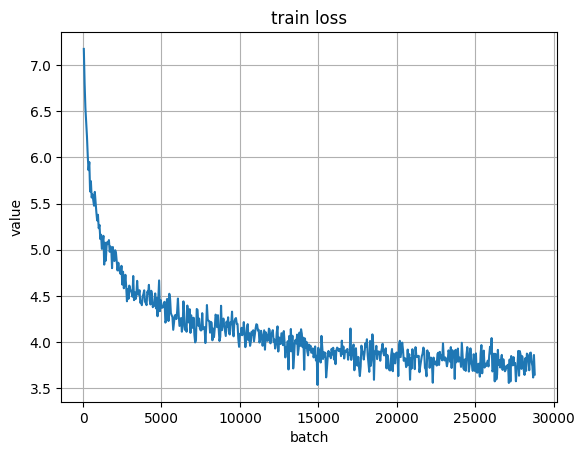

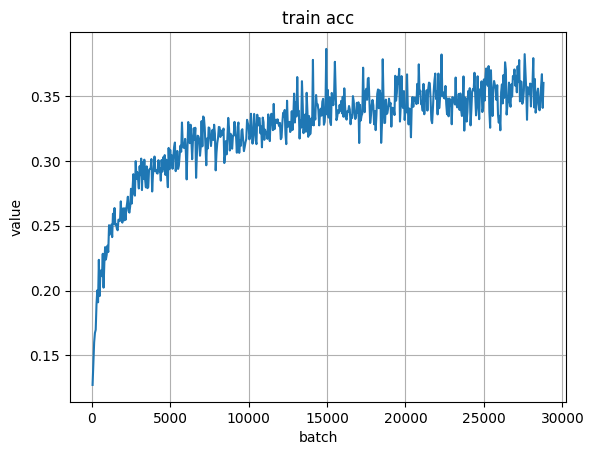

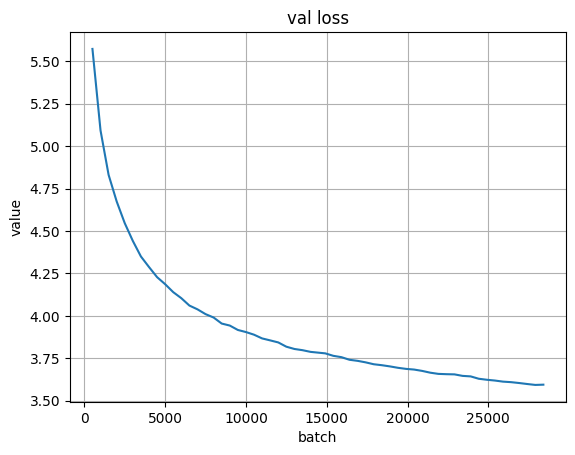

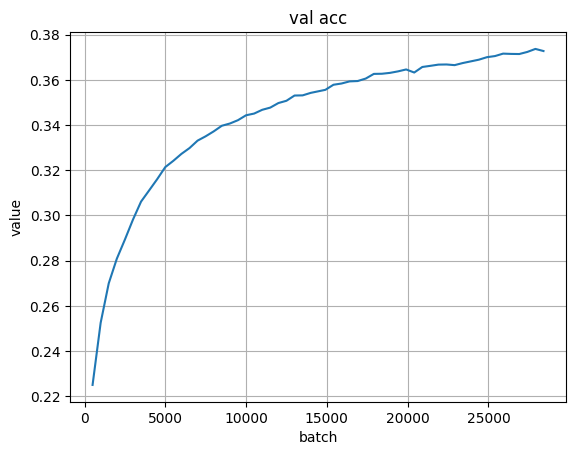

In [46]:
for loop_type in ("train", "val"):
    for metric in ("loss", "acc"):
        df = pd.read_csv(f"csv_log/{loop_type}_{metric}.csv")

        plt.figure()
        plt.plot(df["Step"], df["Value"])
        plt.xlabel("batch")
        plt.ylabel("value")
        plt.title(f"{loop_type} {metric}")
        plt.grid()
        plt.show()

The result:
- test loss: 3.5758
- test top 1 accuracy: 0.3755